# Emotion Classifier - RAG-Based Mental Health Support Chatbot

# 1. Environment Setup

In [ ]:
!pip install -q transformers datasets evaluate accelerate gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 39.0 MB/s eta 0:00:00


In [ ]:
import os
import numpy as np
import pandas as pd
from IPython.display import display
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

import spacy
import gensim.downloader as gensim_api
from collections import Counter
from datasets import load_dataset

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence
import torch.optim as optim

from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 2. Data Ingestion

# 2.1. Data Loading

In [ ]:
# Load the standard split (20,000 examples)
dataset = load_dataset("dair-ai/emotion", "split")
print(dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})


## 2.2. Target Distribution

In [ ]:
label_mapping = {
    0: 'sadness (0)',
    1: 'joy (1)',
    2: 'love (2)',
    3: 'anger (3)',
    4: 'fear (4)',
    5: 'surprise (5)'
}

In [ ]:
df_train = pd.DataFrame(dataset['train'])
df_train['emotion'] = df_train['label'].map(label_mapping)

emotion_percentage = df_train['emotion'].value_counts(normalize=True).mul(100).reset_index()
emotion_percentage.columns = ['emotion', 'percentage']

print("=== Class Distribution ===")
display(emotion_percentage)

=== Class Distribution ===


,emotion,percentage
0,joy (1),33.51250
1,sadness (0),29.16250
2,anger (3),13.49375
3,fear (4),12.10625
4,love (2),8.15000
5,surprise (5),3.57500


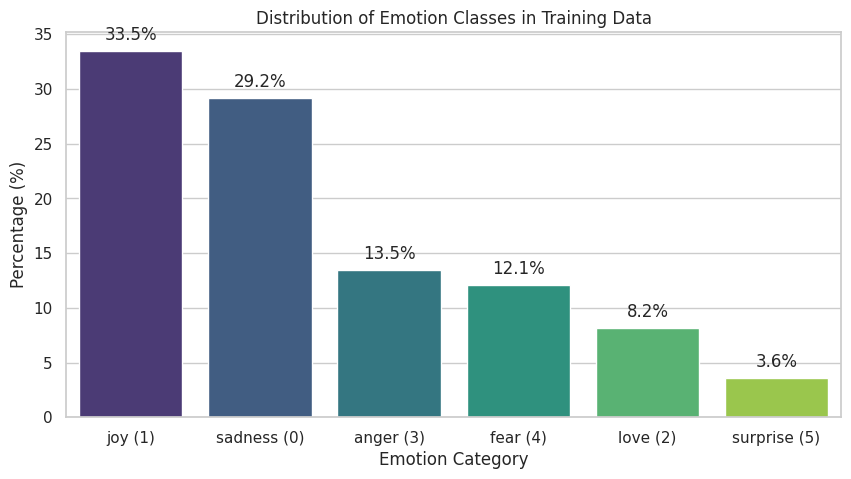

In [ ]:
plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=emotion_percentage,
    x='emotion',
    y='percentage',
    order=emotion_percentage['emotion'],
    palette='viridis',
    hue='emotion',
    legend=False
)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom',
                xytext=(0, 5), textcoords='offset points'
    )

plt.title('Distribution of Emotion Classes in Training Data')
plt.xlabel('Emotion Category')
plt.ylabel('Percentage (%)')
plt.show()

* Target classes are imbalanced.

## 2.3. Data overview

In [ ]:
pd.set_option('display.max_colwidth', None)
display(df_train[['text', 'emotion']].sample(10, random_state=42))

,text,emotion
8756,ive made it through a week i just feel beaten down,sadness (0)
4660,i feel this strategy is worthwhile,joy (1)
6095,i feel so worthless and weak what does he have to say that s what i want to find out,sadness (0)
304,i feel clever nov,joy (1)
8241,im moved in ive been feeling kind of gloomy,sadness (0)
9577,i allowed myself to feel the really shitty feelings while i was running because a the endorphins were flowing so it hurt less and b so i could pretend i was running away from them,sadness (0)
1035,i feel confused too,fear (4)
9976,i feel like a crappy mummy if were stuck in but there are days where i really cant face much else then venturing out to the garden at pm,sadness (0)
7872,i feel like i liked my hair much better before i was using a sulfate free brand and i believe i am using a reputable brand,love (2)
8341,i feel the self pressured expectation to keep up to date with our family events so in order to assuage the guilt here we go,fear (4)


* All data is lowercased and stripped of punctuation.
* The data has typos and contractions.
* Subword tokenization techniques can handle typos and contractions.
* GloVe contains the common contractions.

## 2.4.Sequence Length Distribution

In [ ]:
nlp = spacy.load("en_core_web_sm", disable=['tagger', 'parser', 'ner', 'lemmatizer'])

In [ ]:
def tokenizer(text):
    return [token.text.lower() for token in nlp(text) if not token.is_punct and not token.is_space]

In [ ]:
sequence_lengths = [len(tokenizer(text)) for text in df_train['text']]

mode_len = pd.Series(sequence_lengths).mode()[0]
percentile_95 = int(np.percentile(sequence_lengths, 95))
percentile_99 = int(np.percentile(sequence_lengths, 99))
max_len = max(sequence_lengths)

print(f"Mode: {mode_len}")
print(f"95th Percentile: {percentile_95}")
print(f"99th Percentile: {percentile_99}")
print(f"Max Length in Training Data: {max_len}")

Mode: 12
95th Percentile: 41
99th Percentile: 53
Max Length in Training Data: 71


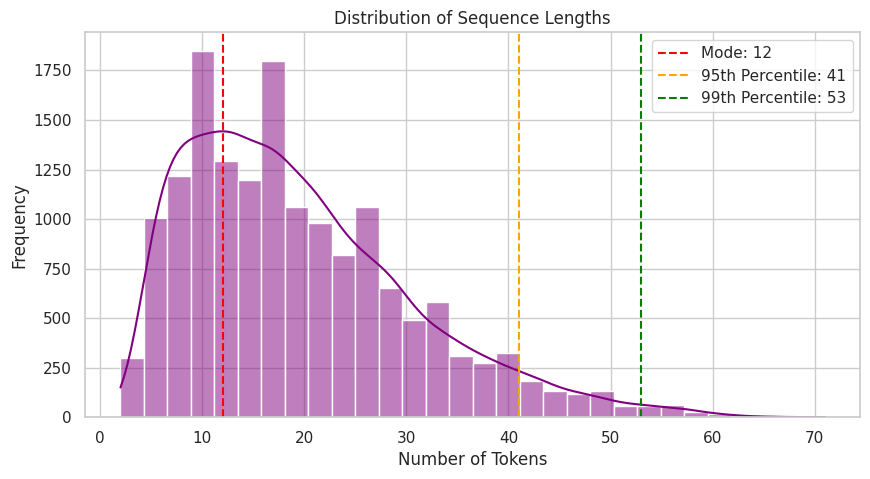

In [ ]:
plt.figure(figsize=(10, 5))

sns.histplot(sequence_lengths, bins=30, kde=True, color='purple')

plt.axvline(mode_len, color='red', linestyle='--', label=f'Mode: {mode_len}')
plt.axvline(percentile_95, color='orange', linestyle='--', label=f'95th Percentile: {percentile_95}')
plt.axvline(percentile_99, color='green', linestyle='--', label=f'99th Percentile: {percentile_99}')

plt.title('Distribution of Sequence Lengths')
plt.xlabel('Number of Tokens')
plt.ylabel('Frequency')
plt.legend()
plt.show()

* Sequences can be truncated at the 99th percentile (53 tokens).

# 3. Tokenization

In [ ]:
def build_vocab(data_split, min_freq=2):
    counter = Counter()

    for text in data_split['text']:
        counter.update(tokenizer(text))

    vocab = {'<pad>': 0, '<unk>': 1}
    idx = 2

    for word, freq in counter.items():
        if freq >= min_freq:
            vocab[word] = idx
            idx += 1

    return vocab

In [ ]:
def text_to_indices(text, vocab):
    tokens = tokenizer(text)
    return [vocab.get(token, 1) for token in tokens]

In [ ]:
vocab_dict = build_vocab(dataset['train'], min_freq=2)
print(f"Total unique words in vocabulary: {len(vocab_dict)}")

Total unique words in vocabulary: 7362


In [ ]:
# Test the tokenizer
sample_tweet = "my name is mohamed xyz. im studying ai."
tokens = tokenizer(sample_tweet)
indices = text_to_indices(sample_tweet, vocab_dict)

print(f"\nSample Tweet: '{sample_tweet}'")
print(f"spaCy Tokens: {tokens}")
print(f"Numerical Indices: {indices}")


Sample Tweet: 'my name is mohamed xyz. im studying ai.'
spaCy Tokens: ['my', 'name', 'is', 'mohamed', 'xyz', 'i', 'm', 'studying', 'ai']
Numerical Indices: [173, 889, 23, 1, 1, 2, 25, 1996, 4913]


# 4. Data Loader

In [ ]:
MAX_LENGTH = 53
pad_idx = 0

def collate_batch(batch):
    label_list = []
    text_list = []

    for item in batch:
        label = item['label']
        text = item['text']

        # Translate the text into indices
        processed_text = torch.tensor(text_to_indices(text, vocab_dict), dtype=torch.int64)

        # Truncate
        if processed_text.size(0) > MAX_LENGTH:
            processed_text = processed_text[:MAX_LENGTH]

        text_list.append(processed_text)
        label_list.append(label)

    # Pad
    text_list = pad_sequence(text_list, padding_value=pad_idx, batch_first=True)

    label_list = torch.tensor(label_list, dtype=torch.int64)

    return text_list, label_list

In [ ]:
batch_size = 64

train_dataloader = DataLoader(
    dataset['train'],
    batch_size=batch_size,
    shuffle=True,
    collate_fn=collate_batch
)

valid_dataloader = DataLoader(
    dataset['validation'],
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collate_batch
)

test_dataloader = DataLoader(
    dataset['test'],
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collate_batch
)

In [ ]:
# Test the dataLoader
sample_text_batch, sample_label_batch = next(iter(train_dataloader))
print(f"Text Batch Shape: {sample_text_batch.shape} -> [Batch Size, Sequence Length]")
print(f"Label Batch Shape: {sample_label_batch.shape} -> [Batch Size]")

Text Batch Shape: torch.Size([64, 53]) -> [Batch Size, Sequence Length]
Label Batch Shape: torch.Size([64]) -> [Batch Size]


# 5. Experimentations

## 5.1. Bi-LSTM Architecture

In [ ]:
class BiLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, n_layers,
                 dropout, pretrained_embeddings=None, freeze_embeddings=False):
        super().__init__()

        # Embedding Layer
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        if pretrained_embeddings is not None:
            self.embedding.weight.data.copy_(pretrained_embeddings)

            if freeze_embeddings:
                self.embedding.weight.requires_grad = False

        # Bi-LSTM Layer
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            num_layers=n_layers,
            bidirectional=True,
            batch_first=True,
            dropout=dropout if n_layers > 1 else 0
        )

        # Fully Connected Layer
        self.fc = nn.Linear(hidden_dim * 2, output_dim)

        # Dropout
        self.dropout = nn.Dropout(dropout)

    def forward(self, text):
        # input shape: [batch_size, sequence_length]

        # embedded shape: [batch_size, sequence_length, embedding_dim]
        embedded = self.dropout(self.embedding(text))

        # output contains the hidden states for EVERY word
        # hidden contains the FINAL hidden state for the whole sentence
        output, (hidden, cell) = self.lstm(embedded)

        # hidden shape: [num_layers * num_directions, batch_size, hidden_dim]
        hidden_forward = hidden[-2, :, :]
        hidden_backward = hidden[-1, :, :]

        # final_hidden shape: [batch_size, hidden_dim * 2]
        final_hidden = self.dropout(torch.cat((hidden_forward, hidden_backward), dim=1))

        # Pass through the linear layer to get our 6 class scores
        return self.fc(final_hidden)



## 5.2. Training and Evaluation Functions

In [ ]:
def train_epoch(model, dataloader, criterion, optimizer, device, desc):
    model.train()
    total_loss = 0
    all_preds = []
    all_targets = []

    progress_bar = tqdm(dataloader, desc=desc, leave=False)

    for data, target in progress_bar:
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()
        output = model(data)

        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(output, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_targets.extend(target.cpu().numpy())

        progress_bar.set_postfix({'loss': f"{loss.item():.4f}"})

    avg_loss = total_loss / len(dataloader)
    acc = accuracy_score(all_targets, all_preds)
    f1 = f1_score(all_targets, all_preds, average='macro')

    return avg_loss, acc, f1

In [ ]:
def evaluate_model(model, dataloader, criterion, device, desc):
    model.eval()
    total_loss = 0
    all_preds = []
    all_targets = []

    progress_bar = tqdm(dataloader, desc=desc, leave=False, colour='green')

    with torch.no_grad():
        for data, target in progress_bar:
            data, target = data.to(device), target.to(device)
            output = model(data)

            loss = criterion(output, target)
            total_loss += loss.item()

            preds = torch.argmax(output, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_targets.extend(target.cpu().numpy())

    avg_loss = total_loss / len(dataloader)
    acc = accuracy_score(all_targets, all_preds)
    f1 = f1_score(all_targets, all_preds, average='macro')

    return avg_loss, acc, f1

In [ ]:
def train(model, train_loader, val_loader, device, best_model_path,
          num_epochs=10, patience=3, lr=1e-3, criterion=None, optimizer=None):

    if criterion is None:
        criterion = nn.CrossEntropyLoss()

    if optimizer is None:
        optimizer = optim.Adam(model.parameters(), lr=lr)

    best_f1 = -1
    epochs_without_improve = 0

    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': [],
        'train_f1': [], 'val_f1': []
    }

    for epoch in range(num_epochs):
        train_desc = f"Epoch {epoch+1}/{num_epochs} [Train]"
        val_desc = f"Epoch {epoch+1}/{num_epochs} [Valid]"

        train_loss, train_acc, train_f1 = train_epoch(model, train_loader, criterion, optimizer, device, train_desc)
        val_loss, val_acc, val_f1 = evaluate_model(model, val_loader, criterion, device, val_desc)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['train_f1'].append(train_f1)
        history['val_f1'].append(val_f1)

        print(f"=== Epoch {epoch+1}/{num_epochs} ===")
        print(f"Train -> Loss: {train_loss:.4f} | Macro F1: {train_f1:.4f} | Acc: {train_acc:.4f}")
        print(f"Val   -> Loss: {val_loss:.4f} | Macro F1: {val_f1:.4f} | Acc: {val_acc:.4f}")

        if val_f1 > best_f1:
            best_f1 = val_f1
            epochs_without_improve = 0
            torch.save(model.state_dict(), best_model_path)
            print(f"***** New best model saved (Validation F1: {best_f1:.4f}) *****")
        else:
            epochs_without_improve += 1
            if epochs_without_improve >= patience:
                print(f"\nEarly stopping triggered: No improvement for {patience} consecutive epochs.")
                break
        print("-" * 30)

    if os.path.exists(best_model_path):
        print(f"\nTraining Complete. Loading the best model weights into memory.")
        model.load_state_dict(torch.load(best_model_path))

    return model, history

## 5.3. Baseline Bi-LSTM

### 5.3.1. Model Instantiation

In [ ]:
INPUT_DIM = len(vocab_dict)
EMBEDDING_DIM = 100
HIDDEN_DIM = 256
OUTPUT_DIM = 6
N_LAYERS = 2
DROPOUT = 0.5

In [ ]:
model = BiLSTM(INPUT_DIM, EMBEDDING_DIM, HIDDEN_DIM, OUTPUT_DIM, N_LAYERS, DROPOUT)
model = model.to(device)

In [ ]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [ ]:
print(model)
print(f'\nThe model has {count_parameters(model):,} trainable parameters')

BiLSTM(
  (embedding): Embedding(7362, 100, padding_idx=0)
  (lstm): LSTM(100, 256, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (fc): Linear(in_features=512, out_features=6, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)

The model has 3,049,422 trainable parameters


### 5.3.2. Training Loop

In [ ]:
baseline_bilstm_model, baseline_bilstm_history = train(
    model=model,
    train_loader=train_dataloader,
    val_loader=valid_dataloader,
    device=device,
    best_model_path="best_baseline_bilstm_model.pth",
    num_epochs=25,
    patience=5
)

Epoch 1/25 [Train]:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 1/25 [Valid]:   0%|          | 0/32 [00:00<?, ?it/s]

=== Epoch 1/25 ===
Train -> Loss: 1.4078 | Macro F1: 0.2673 | Acc: 0.4573
Val   -> Loss: 1.1483 | Macro F1: 0.4089 | Acc: 0.6120
***** New best model saved (Validation F1: 0.4089) *****
------------------------------


Epoch 2/25 [Train]:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 2/25 [Valid]:   0%|          | 0/32 [00:00<?, ?it/s]

...

Epoch 23/25 [Valid]:   0%|          | 0/32 [00:00<?, ?it/s]

=== Epoch 23/25 ===
Train -> Loss: 0.1334 | Macro F1: 0.9178 | Acc: 0.9420
Val   -> Loss: 0.1227 | Macro F1: 0.9104 | Acc: 0.9350
------------------------------


Epoch 24/25 [Train]:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 24/25 [Valid]:   0%|          | 0/32 [00:00<?, ?it/s]

=== Epoch 24/25 ===
Train -> Loss: 0.1300 | Macro F1: 0.9184 | Acc: 0.9439
Val   -> Loss: 0.1173 | Macro F1: 0.9218 | Acc: 0.9410

Early stopping triggered: No improvement for 5 consecutive epochs.

Training Complete. Loading the best model weights into memory.


In [ ]:
!cp "/content/best_baseline_bilstm_model.pth" "/content/drive/MyDrive/Colab Notebooks/ITI/NLP/Project/best_baseline_bilstm_model.pth"

In [ ]:
baseline_bilstm_path = "/content/drive/MyDrive/Colab Notebooks/ITI/NLP/Project/best_baseline_bilstm_model.pth"

baseline_bilstm_model = BiLSTM(INPUT_DIM, EMBEDDING_DIM, HIDDEN_DIM, OUTPUT_DIM, N_LAYERS, DROPOUT)
baseline_bilstm_model = baseline_bilstm_model.to(device)

baseline_bilstm_model.load_state_dict(torch.load(baseline_bilstm_path))

<All keys matched successfully>

### 5.3.3. Learning Curves

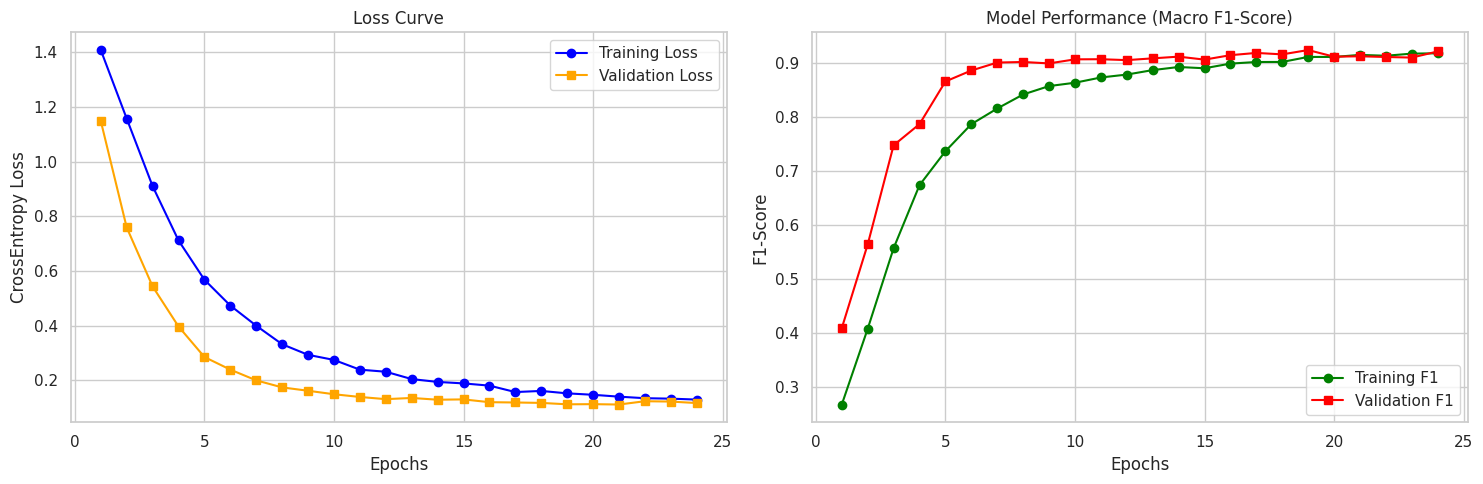

In [ ]:
epochs = range(1, len(baseline_bilstm_history['train_loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(epochs, baseline_bilstm_history['train_loss'], label='Training Loss', marker='o', color='blue')
ax1.plot(epochs, baseline_bilstm_history['val_loss'], label='Validation Loss', marker='s', color='orange')
ax1.set_title('Loss Curve')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('CrossEntropy Loss')
ax1.legend()

ax2.plot(epochs, baseline_bilstm_history['train_f1'], label='Training F1', marker='o', color='green')
ax2.plot(epochs, baseline_bilstm_history['val_f1'], label='Validation F1', marker='s', color='red')
ax2.set_title('Model Performance (Macro F1-Score)')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('F1-Score')
ax2.legend()

plt.tight_layout()
plt.show()

### 5.3.4. Error Analysis

In [ ]:
def plot_confusion_matrix(model, dataloader, device, normalize=None):
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for data, target in dataloader:
            data, target = data.to(device), target.to(device)
            output = model(data)

            preds = torch.argmax(output, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_targets.extend(target.cpu().numpy())

    cm = confusion_matrix(all_targets, all_preds, normalize=normalize)

    class_names = ["sadness", "joy", "love", "anger", "fear", "surprise"]

    annotaion_format = "d" if normalize is None else ".2%"

    plt.figure(figsize=(8, 5))
    sns.heatmap(cm, annot=True, fmt=annotaion_format, cmap="Blues", xticklabels=class_names, yticklabels=class_names)

    plt.title('Emotion Classification Confusion Matrix')
    plt.ylabel('True Emotion')
    plt.xlabel('Predicted Emotion')
    plt.show()

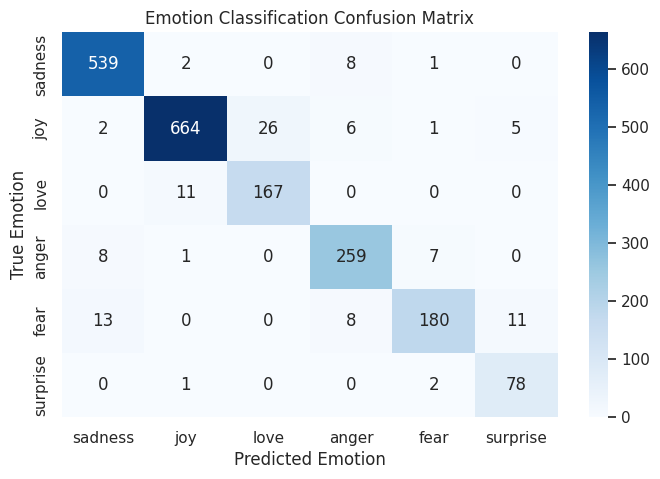

In [ ]:
plot_confusion_matrix(baseline_bilstm_model, valid_dataloader, device)

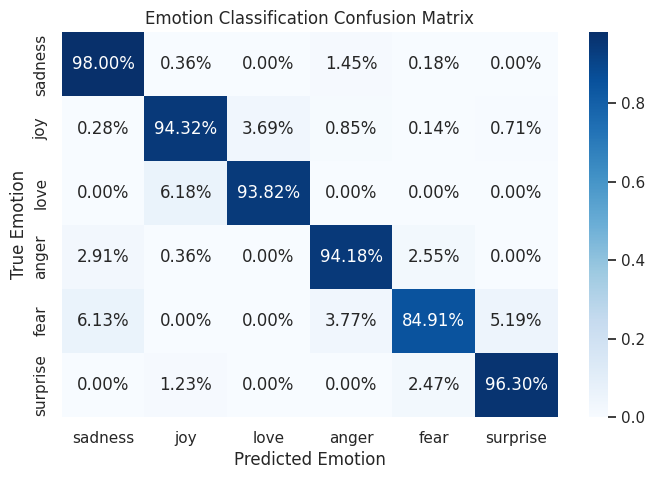

In [ ]:
plot_confusion_matrix(baseline_bilstm_model, valid_dataloader, device, normalize="true")

* The model confuses (Joy vs. Love), (Fear vs. Sadness), and (Fear vs. Surprise)

## 5.4. Bi-LSTM with GloVe

### 5.4.1. GloVe Embeddings

* `glove-twitter-100` is trained on data from Twitter so it maches the same informal language in the emotion dataset that is also collected from Twitter.

In [ ]:
glove_twitter = gensim_api.load("glove-twitter-100")

[==================================================] 100.0% 387.1/387.1MB downloaded


In [ ]:
embedding_matrix = np.zeros((len(vocab_dict), 100))
words_found = 0

# Map the weights
for word, idx in vocab_dict.items():
    if word in glove_twitter:
        embedding_matrix[idx] = glove_twitter[word]
        words_found += 1
    else:
        # If the word is unknown, initialize it with random noise similar to GloVe's standard distribution
        embedding_matrix[idx] = np.random.normal(scale=0.6, size=(100,))

embedding_matrix[vocab_dict['<pad>']] = np.zeros(100)

glove_embeddings = torch.tensor(embedding_matrix, dtype=torch.float32)

print(f"Total vocabulary size: {len(vocab_dict):,}")
print(f"Words found in GloVe: {words_found:,}")
print(f"Match rate: {(words_found / len(vocab_dict)) * 100:.2f}%")

Total vocabulary size: 7,362
Words found in GloVe: 7,340
Match rate: 99.70%


### 5.4.2. Model Instantiation

In [ ]:
glove_bilstm_model = BiLSTM(
    INPUT_DIM,
    EMBEDDING_DIM,
    HIDDEN_DIM,
    OUTPUT_DIM,
    N_LAYERS,
    DROPOUT,
    pretrained_embeddings=glove_embeddings,
    freeze_embeddings=False
)

glove_bilstm_model = glove_bilstm_model.to(device)

In [ ]:
print(glove_bilstm_model)
print(f'\nThe model has {count_parameters(glove_bilstm_model):,} trainable parameters')

BiLSTM(
  (embedding): Embedding(7362, 100, padding_idx=0)
  (lstm): LSTM(100, 256, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (fc): Linear(in_features=512, out_features=6, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)

The model has 3,049,422 trainable parameters


### 5.4.3. Training Loop

In [ ]:
glove_bilstm_model, glove_bilstm_history = train(
    model=glove_bilstm_model,
    train_loader=train_dataloader,
    val_loader=valid_dataloader,
    device=device,
    best_model_path="best_glove_bilstm_model.pth",
    num_epochs=25,
    patience=5
)

Epoch 1/25 [Train]:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 1/25 [Valid]:   0%|          | 0/32 [00:00<?, ?it/s]

=== Epoch 1/25 ===
Train -> Loss: 1.4040 | Macro F1: 0.1936 | Acc: 0.4685
Val   -> Loss: 1.0959 | Macro F1: 0.2377 | Acc: 0.5730
***** New best model saved (Validation F1: 0.2377) *****
------------------------------


Epoch 2/25 [Train]:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 2/25 [Valid]:   0%|          | 0/32 [00:00<?, ?it/s]

...

Epoch 19/25 [Valid]:   0%|          | 0/32 [00:00<?, ?it/s]

=== Epoch 19/25 ===
Train -> Loss: 0.0925 | Macro F1: 0.9310 | Acc: 0.9553
Val   -> Loss: 0.1221 | Macro F1: 0.9147 | Acc: 0.9400
------------------------------


Epoch 20/25 [Train]:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 20/25 [Valid]:   0%|          | 0/32 [00:00<?, ?it/s]

=== Epoch 20/25 ===
Train -> Loss: 0.0924 | Macro F1: 0.9327 | Acc: 0.9563
Val   -> Loss: 0.1201 | Macro F1: 0.9180 | Acc: 0.9395

Early stopping triggered: No improvement for 5 consecutive epochs.

Training Complete. Loading the best model weights into memory.


In [ ]:
!cp "/content/best_glove_bilstm_model.pth" "/content/drive/MyDrive/Colab Notebooks/ITI/NLP/Project/best_glove_bilstm_model.pth"

In [ ]:
glove_bilstm_path = "/content/drive/MyDrive/Colab Notebooks/ITI/NLP/Project/best_glove_bilstm_model.pth"

glove_bilstm_model = BiLSTM(
    INPUT_DIM,
    EMBEDDING_DIM,
    HIDDEN_DIM,
    OUTPUT_DIM,
    N_LAYERS,
    DROPOUT,
    pretrained_embeddings=glove_embeddings,
    freeze_embeddings=False
)
glove_bilstm_model = glove_bilstm_model.to(device)

glove_bilstm_model.load_state_dict(torch.load(glove_bilstm_path))

<All keys matched successfully>

### 5.4.4. Learning Curves

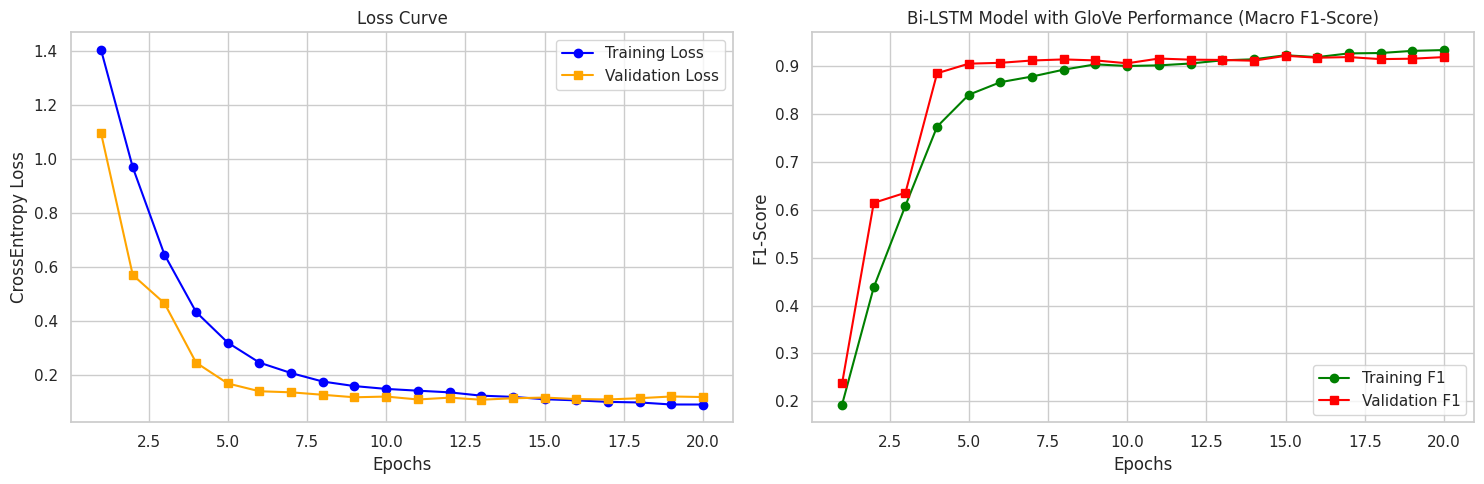

In [ ]:
epochs = range(1, len(glove_bilstm_history['train_loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(epochs, glove_bilstm_history['train_loss'], label='Training Loss', marker='o', color='blue')
ax1.plot(epochs, glove_bilstm_history['val_loss'], label='Validation Loss', marker='s', color='orange')
ax1.set_title('Loss Curve')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('CrossEntropy Loss')
ax1.legend()

ax2.plot(epochs, glove_bilstm_history['train_f1'], label='Training F1', marker='o', color='green')
ax2.plot(epochs, glove_bilstm_history['val_f1'], label='Validation F1', marker='s', color='red')
ax2.set_title('Bi-LSTM Model with GloVe Performance (Macro F1-Score)')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('F1-Score')
ax2.legend()

plt.tight_layout()
plt.show()

### 5.4.5. Error Analysis

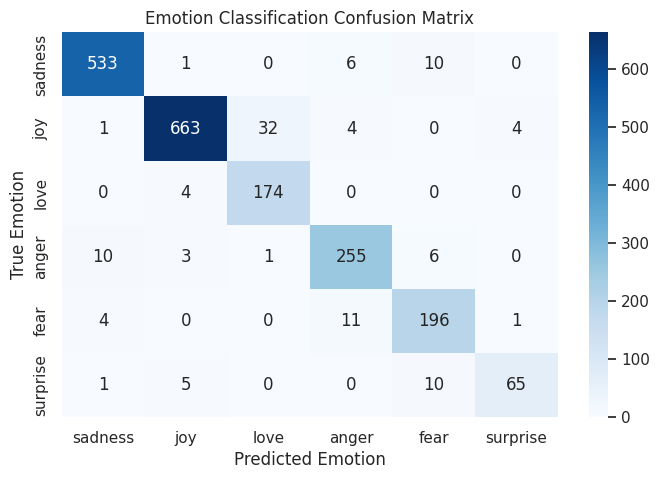

In [ ]:
plot_confusion_matrix(glove_bilstm_model, valid_dataloader, device)

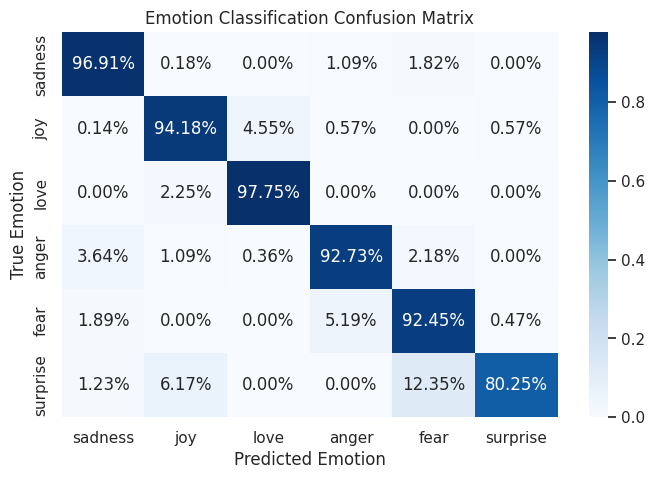

In [ ]:
plot_confusion_matrix(glove_bilstm_model, valid_dataloader, device, normalize="true")

* The model still confuses (Joy vs. Love) and (Fear vs. Surprise)

## 5.5. Model Comparison

In [ ]:
def print_model_report(model, dataloader, device, model_name):
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for data, target in dataloader:
            data, target = data.to(device), target.to(device)
            output = model(data)

            preds = torch.argmax(output, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_targets.extend(target.cpu().numpy())

    class_names = ["sadness", "joy", "love", "anger", "fear", "surprise"]

    print(f"=== Classification Report: {model_name} ===")
    print(classification_report(all_targets, all_preds, target_names=class_names, digits=4))
    print("\n")

In [ ]:
print_model_report(baseline_bilstm_model, valid_dataloader, device, "Baseline Bi-LSTM")
print_model_report(glove_bilstm_model, valid_dataloader, device, "GloVe Bi-LSTM")

=== Classification Report: Baseline Bi-LSTM ===
              precision    recall  f1-score   support

     sadness     0.9591    0.9800    0.9694       550
         joy     0.9779    0.9432    0.9602       704
        love     0.8653    0.9382    0.9003       178
       anger     0.9217    0.9418    0.9317       275
        fear     0.9424    0.8491    0.8933       212
    surprise     0.8298    0.9630    0.8914        81

    accuracy                         0.9435      2000
   macro avg     0.9160    0.9359    0.9244      2000
weighted avg     0.9452    0.9435    0.9436      2000



=== Classification Report: GloVe Bi-LSTM ===
              precision    recall  f1-score   support

     sadness     0.9709    0.9691    0.9700       550
         joy     0.9808    0.9418    0.9609       704
        love     0.8406    0.9775    0.9039       178
       anger     0.9239    0.9273    0.9256       275
        fear     0.8829    0.9245    0.9032       212
    surprise     0.9286    0.8025    

* The evaluation metric is the Macro F1-Score because it is robust to imbalance and treats all classes equally.
* However, the difference between the Macro F1-Score of both models is almost negligible (0.0037).
* For the minority class "surprise", the baseline model achieved high recall and low precision while the the GloVe achieved high precision and low recall.
* GloVe achieved a high F1-Score for 4 out of 6 classes.

> GloVe is more reliable due to the pre-trained weights that can handle unseen text (OOV Resilience), unlike the baseline model that builds its vocab from the training set only.

# 6. Hyperparameter Tuning

## 6.1. Class-Weighted Loss

### 6.1.1. Model Instantiation

In [ ]:
weighted_glove_model = BiLSTM(
    INPUT_DIM,
    EMBEDDING_DIM,
    HIDDEN_DIM,
    OUTPUT_DIM,
    N_LAYERS,
    DROPOUT,
    pretrained_embeddings=glove_embeddings,
    freeze_embeddings=False
).to(device)

### 6.1.2. Class Weights

In [ ]:
train_labels = dataset['train']['label']

unique_classes = np.unique(train_labels)
calculated_weights = compute_class_weight(class_weight='balanced',
                                          classes=unique_classes,
                                          y=train_labels)

class_weights_tensor = torch.tensor(calculated_weights, dtype=torch.float32).to(device)

In [ ]:
emotion_names = ["sadness", "joy", "love", "anger", "fear", "surprise"]
for name, weight in zip(emotion_names, calculated_weights):
    print(f"{name}: {weight:.4f}")

sadness: 0.5715
joy: 0.4973
love: 2.0450
anger: 1.2351
fear: 1.3767
surprise: 4.6620


In [ ]:
weighted_criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

### 6.1.3. Training Loop

In [ ]:
weighted_glove_model, weighted_glove_history = train(
    model=weighted_glove_model,
    train_loader=train_dataloader,
    val_loader=valid_dataloader,
    device=device,
    criterion=weighted_criterion,
    best_model_path="best_weighted_glove.pth",
    num_epochs=25,
    patience=5
)

Epoch 1/25 [Train]:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 1/25 [Valid]:   0%|          | 0/32 [00:00<?, ?it/s]

=== Epoch 1/25 ===
Train -> Loss: 1.6191 | Macro F1: 0.2607 | Acc: 0.3023
Val   -> Loss: 1.1475 | Macro F1: 0.4315 | Acc: 0.4490
***** New best model saved (Validation F1: 0.4315) *****
------------------------------


Epoch 2/25 [Train]:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 2/25 [Valid]:   0%|          | 0/32 [00:00<?, ?it/s]

...

Epoch 20/25 [Valid]:   0%|          | 0/32 [00:00<?, ?it/s]

=== Epoch 20/25 ===
Train -> Loss: 0.1143 | Macro F1: 0.9257 | Acc: 0.9463
Val   -> Loss: 0.1256 | Macro F1: 0.9192 | Acc: 0.9400
------------------------------


Epoch 21/25 [Train]:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 21/25 [Valid]:   0%|          | 0/32 [00:00<?, ?it/s]

=== Epoch 21/25 ===
Train -> Loss: 0.1065 | Macro F1: 0.9294 | Acc: 0.9475
Val   -> Loss: 0.1392 | Macro F1: 0.9179 | Acc: 0.9395

Early stopping triggered: No improvement for 5 consecutive epochs.

Training Complete. Loading the best model weights into memory.


In [ ]:
!cp "/content/best_weighted_glove.pth" "/content/drive/MyDrive/Colab Notebooks/ITI/NLP/Project/best_weighted_glove.pth"

### 6.1.4. Learning Curves

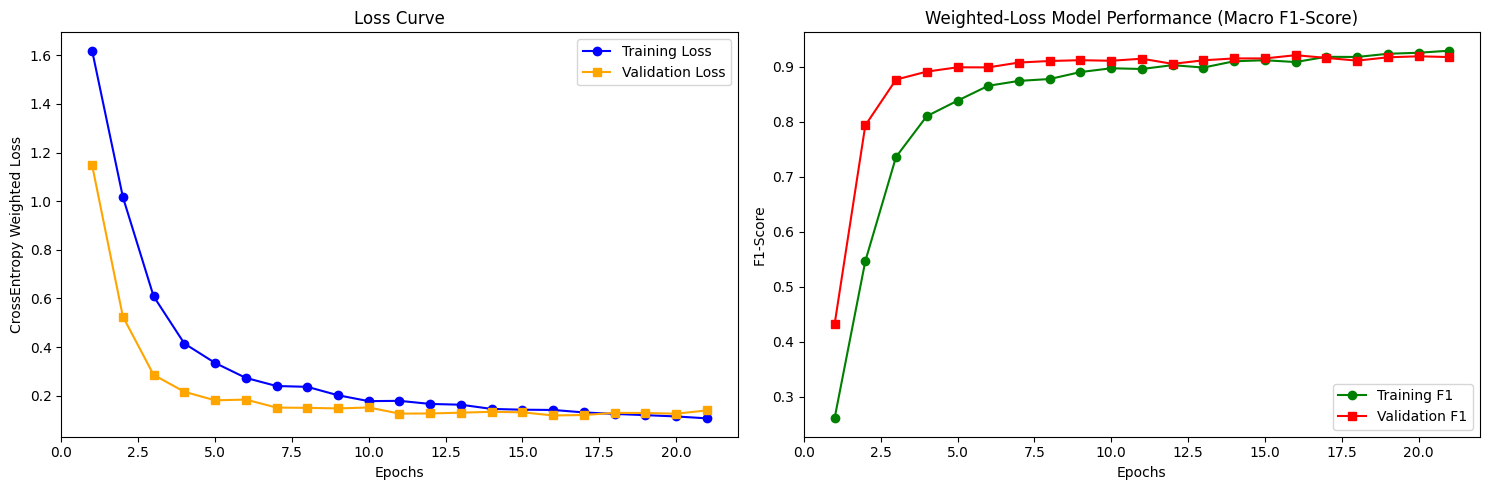

In [ ]:
epochs = range(1, len(weighted_glove_history['train_loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(epochs, weighted_glove_history['train_loss'], label='Training Loss', marker='o', color='blue')
ax1.plot(epochs, weighted_glove_history['val_loss'], label='Validation Loss', marker='s', color='orange')
ax1.set_title('Loss Curve')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('CrossEntropy Weighted Loss')
ax1.legend()

ax2.plot(epochs, weighted_glove_history['train_f1'], label='Training F1', marker='o', color='green')
ax2.plot(epochs, weighted_glove_history['val_f1'], label='Validation F1', marker='s', color='red')
ax2.set_title('Weighted-Loss Model Performance (Macro F1-Score)')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('F1-Score')
ax2.legend()

plt.tight_layout()
plt.show()

### 6.1.5. Error Analysis

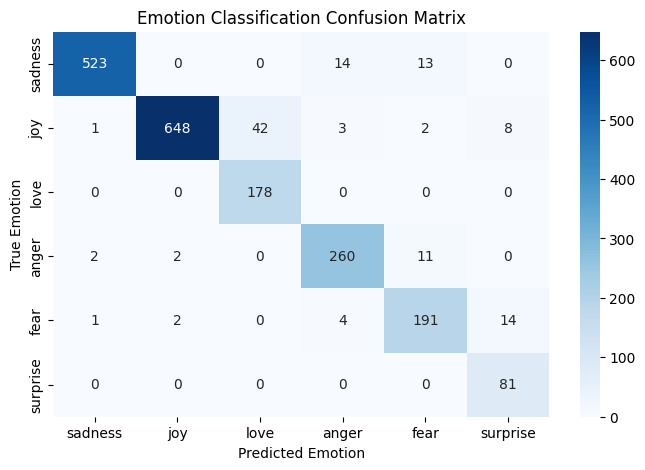

In [ ]:
plot_confusion_matrix(weighted_glove_model, valid_dataloader, device)

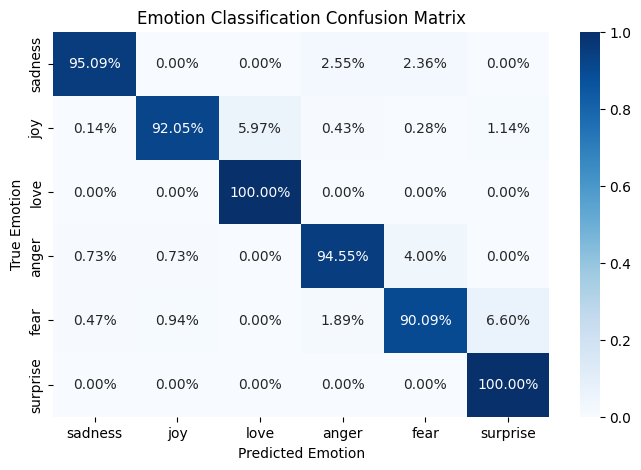

In [ ]:
plot_confusion_matrix(weighted_glove_model, valid_dataloader, device, normalize="true")

### 6.1.6. Model Comparison

In [ ]:
print_model_report(glove_bilstm_model, valid_dataloader, device, "GloVe Bi-LSTM")
print_model_report(weighted_glove_model, valid_dataloader, device, "Weighted-Loss GloVe Bi-LSTM")

=== Classification Report: GloVe Bi-LSTM ===
              precision    recall  f1-score   support

     sadness     0.9709    0.9691    0.9700       550
         joy     0.9808    0.9418    0.9609       704
        love     0.8406    0.9775    0.9039       178
       anger     0.9239    0.9273    0.9256       275
        fear     0.8829    0.9245    0.9032       212
    surprise     0.9286    0.8025    0.8609        81

    accuracy                         0.9430      2000
   macro avg     0.9213    0.9238    0.9207      2000
weighted avg     0.9453    0.9430    0.9433      2000



=== Classification Report: Weighted-Loss GloVe Bi-LSTM ===
              precision    recall  f1-score   support

     sadness     0.9924    0.9509    0.9712       550
         joy     0.9939    0.9205    0.9558       704
        love     0.8091    1.0000    0.8945       178
       anger     0.9253    0.9455    0.9353       275
        fear     0.8802    0.9009    0.8904       212
    surprise     0.7864   

* The weighted loss slightly increased the Macro F1-Score by (+0.006)
* Although the weighted loss increased the recall by (+0.0292), it decreased the precision by (-0.0234)

> For this problem, precision (Of all the instances the model predicted as positive, how many were actually correct?) is priortized over recall (Of all the true positive instances, how many did the model actually catch?). So, the **GloVe Bi-LSTM model without weighted loss** is more reliable.

## 6.2. Number of Layers

## 6.3. Dropout Ratio